In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Currently using {DEVICE}")

Currently using cuda


In [2]:
from src.data_import import load_fashion_mnist

train_loader, test_loader = load_fashion_mnist(32, shuffle=True, class_subset=[5])

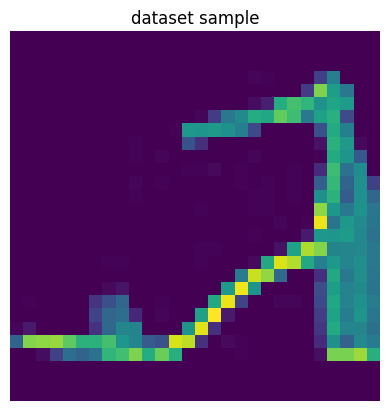

label: 5


In [3]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample")
#print label
print("label:", _[0].item())

In [4]:
from src.model import EnergyHead, EBM

n_heads = 4

model = EBM(in_dim=28*28, mid_dim=150, n_heads=n_heads, batch_size=32)

model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-3): 4 x EnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
        (6): Flatten(start_dim=1, end_dim=-1)
        (7): Linear(in_features=3136, out_features=49, bias=True)
        (8): GELU(approximate='none')
        (9): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [5]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=(1, 28, 28), buffer_size=200, noise_fraction=0.05, device=DEVICE)
total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=64)
total_correlation_estimator.to(DEVICE)

In [ ]:
from src.train import train_one_epoch_TC
#torch.autograd.set_detect_anomaly(True, check_nan=False)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.0, 0.999))

for epoch in range(3):
    epoch_loss = train_one_epoch_TC(

        model, 
        total_correlation_estimator, 
        sampler, 
        train_loader, 
        optimizer,

        sample_steps=60,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=0.5,
        tc_reg=0.1,

        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

100%|██████████| 188/188 [01:14<00:00,  2.52it/s]

  CD:     0.0163
  Reg:    0.0029
  TC:     0.0484
  E_real: -0.0012
  E_fake: -0.0182
  Gap:    0.0170
Epoch 1, Loss: 0.0676


EBM DIAGNOSTICS

[1] Energy on real data


  Train  →  mean=-0.0073,  std=0.0045
  Test   →  mean=-0.0074,  std=0.0044
  |E_test - E_train| = 0.0001  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.0135,  std=0.0041
  Gap (E_real_train - E_fake) = 0.0062  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=0.1055,  std=0.0047
  Gap (E_real_train - E_noise) = -0.1128  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=-0.0421,  std=0.0044
  Head 1  →  mean=-0.0791,  std=0.0073
  Head 2  →  mean=0.1786,  std=0.0031
  Head 3  →  mean=-0.0653,  std=0.0040
  Max off-diagonal correlation: 0.9597  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 200 / 200
  Buffer samples  →  mean=0.1362,  std=0.2763,  min=-1.0000,  max=1.0000

[6] Visual samples (Langevin from noise)


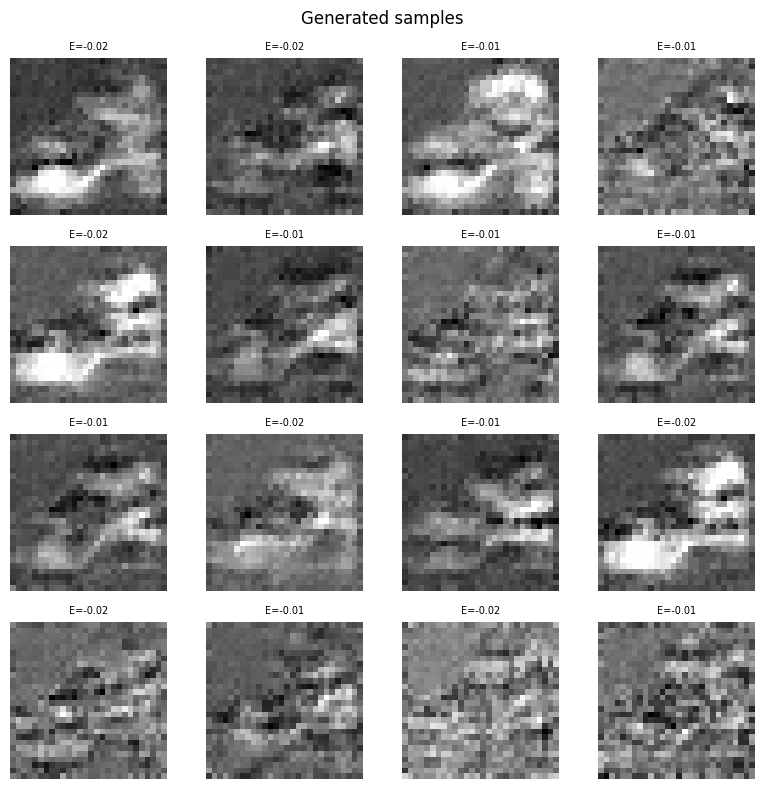


DONE


In [7]:
from src.diagnostic import diagnose

diagnose(model, sampler, train_loader, test_loader, device=DEVICE, n_samples=16)

In [8]:
samples = sampler.generate(10, steps=200, step_size=10, noise_std=0.005)

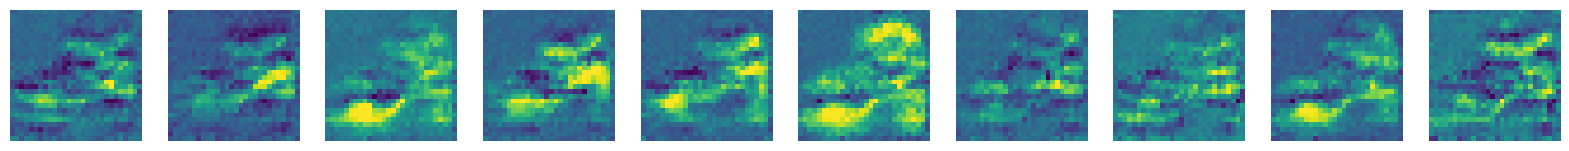

In [9]:
show_grid(samples, 10)

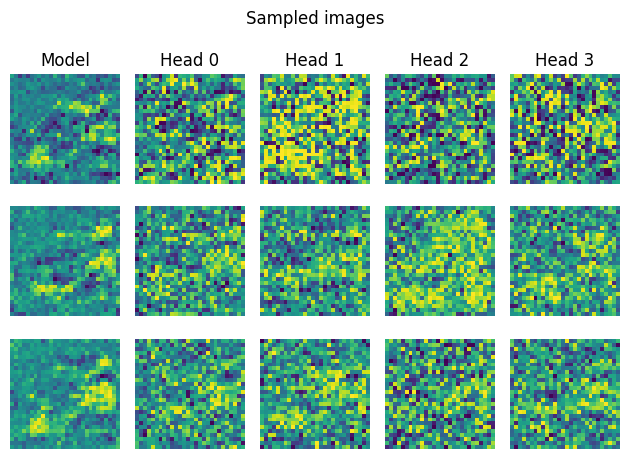

In [12]:
from src.plot import visualize_heads

fig = visualize_heads(model, sampler.buffer, DEVICE, k=3, cmap="viridis")